# Text Mining Groupwork: Tokenization, Stemming, Lemmatization, BoW, and TF-IDF

Use the `SMSSpamCollection` corpus at Dataset: SMSSpamCollection @UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/228/sms+spam+collection) to build a preprocessing and vectorization pipeline.

### Objective: 
This assignment highlights two comparisons:

1) Stemming vs Lemmatization — measure how each preprocessing method affects the vocabulary, interpretability, and TF-IDF features.
2) Bag-of-Words (BoW) vs TF-IDF — compare raw counts vs. TF-IDF weighting on the same cleaned text to see how feature importance changes.

### Tasks:
- tokenize the text
- remove stopwords
- apply stemming and lemmatization
- compare stemming and lemmatization
- apply Bag-of-Words and TF-IDF
- compare Bag-of-Words and TF-IDF

### Deliverables:

- A notebook with the required code cells completed.
- Tables and plots showing the top features for both comparisons.
- A short written conclusion (3–5 sentences).

In [ ]:
import os
import re
from collections import Counter

# Keep generated support files inside the project folder.
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".matplotlib_cache"))
NLTK_DATA_DIR = os.path.abspath("nltk_data")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(NLTK_DATA_DIR, exist_ok=True)

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.data.path.insert(0, NLTK_DATA_DIR)
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, download_dir=NLTK_DATA_DIR, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


In [2]:
data_path = "sms+spam+collection/SMSSpamCollection"

df = pd.read_csv(
    data_path,
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="latin-1",
)

print(f"Rows: {len(df):,}")
display(df.head())
display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))


Rows: 5,572


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,label,count
0,ham,4825
1,spam,747


In [3]:
def preprocess_text(text):
    """Tokenize, remove stopwords, stem, and lemmatize one SMS message."""
    cleaned = re.sub(r"[^a-zA-Z]", " ", text.lower())
    tokens = [token for token in word_tokenize(cleaned) if token.isalpha()]
    no_stop_tokens = [token for token in tokens if token not in STOP_WORDS]
    stemmed_tokens = [stemmer.stem(token) for token in no_stop_tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in no_stop_tokens]

    return {
        "tokens": tokens,
        "no_stop_tokens": no_stop_tokens,
        "stemmed_tokens": stemmed_tokens,
        "lemmatized_tokens": lemmatized_tokens,
    }

processed = df["text"].apply(preprocess_text).apply(pd.Series)
df = pd.concat([df, processed], axis=1)
df["stemmed_text"] = df["stemmed_tokens"].apply(" ".join)
df["lemmatized_text"] = df["lemmatized_tokens"].apply(" ".join)

preview_cols = ["label", "text", "no_stop_tokens", "stemmed_tokens", "lemmatized_tokens"]
display(df[preview_cols].head())


,label,text,no_stop_tokens,stemmed_tokens,lemmatized_tokens
0,ham,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre...","[go, jurong, point, crazy, available, bugis, n..."
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,...","[free, entri, wkli, comp, win, fa, cup, final,...","[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,U dun say so early hor... U c already then say...,"[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]","[u, dun, say, early, hor, u, c, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, think, goes, usf, lives, around, though]","[nah, think, goe, usf, live, around, though]","[nah, think, go, usf, life, around, though]"


,representation,vocabulary_size
0,Stemmed,3172
1,Lemmatized,3464


,only_in_stemmed_sample,only_in_lemmatized_sample
0,abil,ability
1,abl,able
2,absolutli,absolutly
3,abus,accidentally
4,accid,accordingly
5,accomod,ache
6,accordingli,acted
7,ach,acting
8,act,activate
9,activ,active


,feature,score,representation
0,call,139.039432,Stemmed TF-IDF
1,ok,106.712818,Stemmed TF-IDF
2,go,100.090452,Stemmed TF-IDF
3,get,97.122560,Stemmed TF-IDF
4,come,84.942510,Stemmed TF-IDF
5,ur,70.254125,Stemmed TF-IDF
6,gt,68.875577,Stemmed TF-IDF
7,lt,68.503552,Stemmed TF-IDF
8,know,67.543627,Stemmed TF-IDF
9,time,67.056435,Stemmed TF-IDF


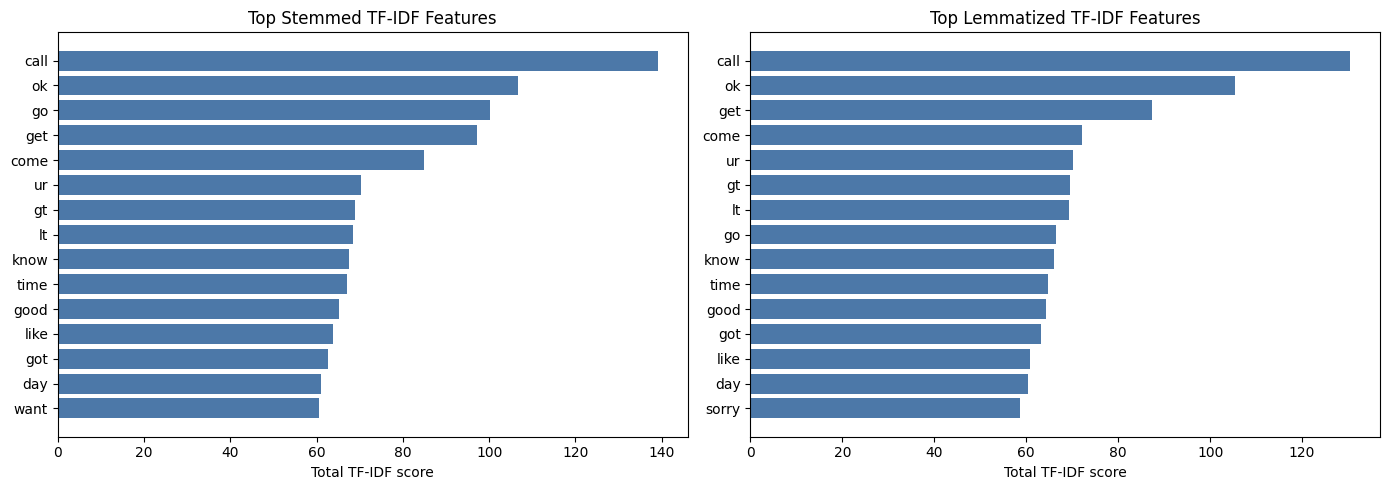

In [4]:
def top_vector_features(matrix, vectorizer, n=20):
    """Return the top n features by total vector weight across the corpus."""
    totals = matrix.sum(axis=0).A1
    features = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({"feature": features, "score": totals})
        .sort_values("score", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

stem_tfidf_vectorizer = TfidfVectorizer(min_df=2)
lemma_tfidf_vectorizer = TfidfVectorizer(min_df=2)

stem_tfidf = stem_tfidf_vectorizer.fit_transform(df["stemmed_text"])
lemma_tfidf = lemma_tfidf_vectorizer.fit_transform(df["lemmatized_text"])

stem_vocab = set(stem_tfidf_vectorizer.get_feature_names_out())
lemma_vocab = set(lemma_tfidf_vectorizer.get_feature_names_out())

vocab_summary = pd.DataFrame(
    {
        "representation": ["Stemmed", "Lemmatized"],
        "vocabulary_size": [len(stem_vocab), len(lemma_vocab)],
    }
)
display(vocab_summary)

unique_comparison = pd.DataFrame(
    {
        "only_in_stemmed_sample": sorted(stem_vocab - lemma_vocab)[:25],
        "only_in_lemmatized_sample": sorted(lemma_vocab - stem_vocab)[:25],
    }
)
display(unique_comparison)

stem_top_tfidf = top_vector_features(stem_tfidf, stem_tfidf_vectorizer, n=15)
lemma_top_tfidf = top_vector_features(lemma_tfidf, lemma_tfidf_vectorizer, n=15)

stem_top_tfidf["representation"] = "Stemmed TF-IDF"
lemma_top_tfidf["representation"] = "Lemmatized TF-IDF"
stem_lemma_top = pd.concat([stem_top_tfidf, lemma_top_tfidf], ignore_index=True)
display(stem_lemma_top)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, table, title in [
    (axes[0], stem_top_tfidf, "Top Stemmed TF-IDF Features"),
    (axes[1], lemma_top_tfidf, "Top Lemmatized TF-IDF Features"),
]:
    ax.barh(table["feature"][::-1], table["score"][::-1], color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel("Total TF-IDF score")
plt.tight_layout()
plt.show()


## Reflections

Lemmatization produced the easier vocabulary to interpret because words usually remain readable dictionary forms, such as `call`, `claim`, or `prize`. Stemming reduced the vocabulary more aggressively, but some stems are truncated and less natural to read, which makes interpretation harder even when the feature space is slightly smaller. BoW surfaced words that occur most often across messages, while TF-IDF gave more weight to words that are frequent in specific messages but less common across the whole corpus. For a downstream spam classifier, I would choose TF-IDF on lemmatized text because it keeps features interpretable while reducing the dominance of very common SMS words.


,feature,score,representation
0,call,641.000000,Bag-of-Words
1,get,408.000000,Bag-of-Words
2,ur,391.000000,Bag-of-Words
3,gt,318.000000,Bag-of-Words
4,lt,316.000000,Bag-of-Words
5,go,315.000000,Bag-of-Words
6,ok,293.000000,Bag-of-Words
7,day,293.000000,Bag-of-Words
8,free,288.000000,Bag-of-Words
9,know,272.000000,Bag-of-Words


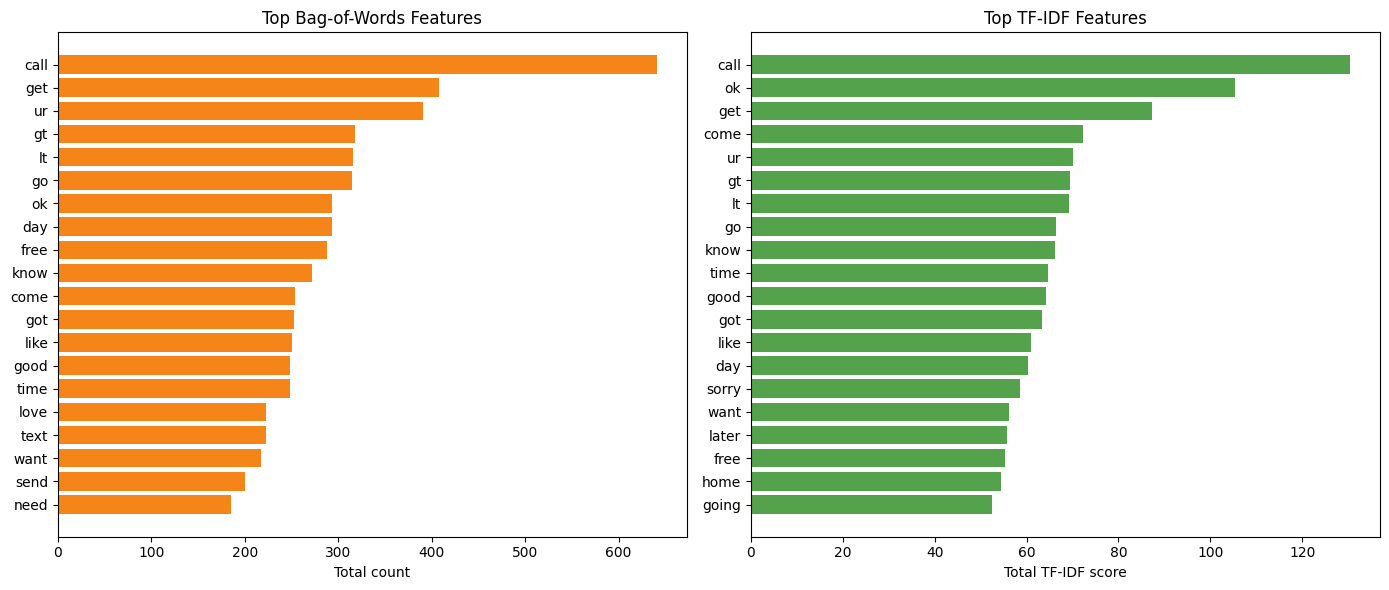

,label,feature,tfidf_score
0,ham,ok,104.346237
1,ham,get,75.210699
2,ham,call,71.234818
3,ham,come,71.199670
4,ham,gt,69.461465
5,ham,lt,69.199620
6,ham,got,62.307550
7,ham,good,62.088220
8,ham,know,61.465858
9,ham,go,61.300557


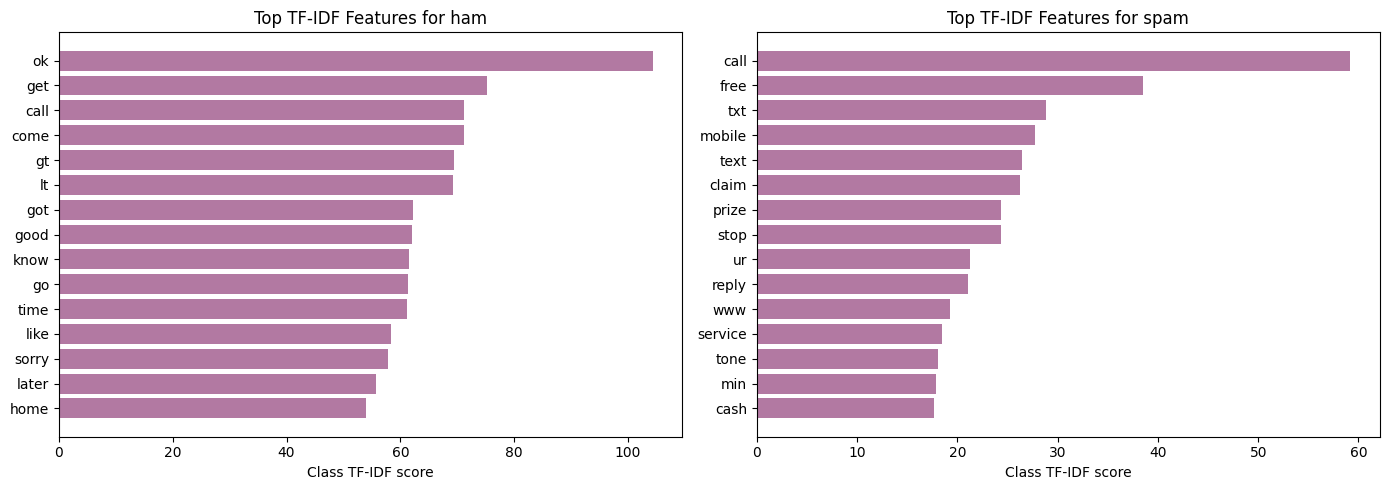

In [5]:
# Compare Bag-of-Words and TF-IDF on the same cleaned lemmatized text.
bow_vectorizer = CountVectorizer(min_df=2)
tfidf_vectorizer = TfidfVectorizer(min_df=2)

bow_matrix = bow_vectorizer.fit_transform(df["lemmatized_text"])
tfidf_matrix = tfidf_vectorizer.fit_transform(df["lemmatized_text"])

bow_top = top_vector_features(bow_matrix, bow_vectorizer, n=20).rename(columns={"score": "count"})
tfidf_top = top_vector_features(tfidf_matrix, tfidf_vectorizer, n=20).rename(columns={"score": "tfidf_score"})

comparison_table = pd.concat(
    [
        bow_top.assign(representation="Bag-of-Words").rename(columns={"count": "score"}),
        tfidf_top.assign(representation="TF-IDF").rename(columns={"tfidf_score": "score"}),
    ],
    ignore_index=True,
)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(bow_top["feature"][::-1], bow_top["count"][::-1], color="#f58518")
axes[0].set_title("Top Bag-of-Words Features")
axes[0].set_xlabel("Total count")

axes[1].barh(tfidf_top["feature"][::-1], tfidf_top["tfidf_score"][::-1], color="#54a24b")
axes[1].set_title("Top TF-IDF Features")
axes[1].set_xlabel("Total TF-IDF score")

plt.tight_layout()
plt.show()

# Class-level TF-IDF comparison helps show terms associated with ham and spam messages.
class_feature_rows = []
features = tfidf_vectorizer.get_feature_names_out()
for label in sorted(df["label"].unique()):
    label_mask = df["label"].eq(label).to_numpy()
    label_scores = tfidf_matrix[label_mask].sum(axis=0).A1
    top_idx = label_scores.argsort()[::-1][:15]
    class_feature_rows.extend(
        {"label": label, "feature": features[i], "tfidf_score": label_scores[i]}
        for i in top_idx
    )

class_tfidf_top = pd.DataFrame(class_feature_rows)
display(class_tfidf_top)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, sorted(df["label"].unique())):
    table = class_tfidf_top[class_tfidf_top["label"] == label]
    ax.barh(table["feature"][::-1], table["tfidf_score"][::-1], color="#b279a2")
    ax.set_title(f"Top TF-IDF Features for {label}")
    ax.set_xlabel("Class TF-IDF score")
plt.tight_layout()
plt.show()
